In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE MASTER VIEW INGESTION & COLUMN INVENTORY (ORIGINAL ORDER)
# ==============================================================================

print("⏳ Loading the Master Analytical View (v_ML_Supervised)...")

query = "SELECT * FROM v_ML_Supervised"

try:
    # 1. Ingest Data
    df_grand = pd.read_sql(query, db_engine)

    # Hygiene: Drop duplicate columns
    df_grand = df_grand.loc[:, ~df_grand.columns.duplicated()]

    print(f"✅ Master View Loaded. Shape: {df_grand.shape}")

    # 2. Full Column Inventory (Preserving View Order)
    print("\n📋 FULL COLUMN INVENTORY (Original Database Order):")
    print("-" * 60)

    # We grab the columns exactly as they come from the DB
    cols = df_grand.columns.tolist()

    # Print in a clean, numbered list
    for i, col in enumerate(cols):
        # We print the type as well for extra context
        dtype = df_grand[col].dtype
        print(f"{i+1:03d}. {col:<40} ({dtype})")

    print("-" * 60)

except Exception as e:
    print(f"🔴 SQL Error: {e}")

⏳ Loading the Master Analytical View (v_ML_Supervised)...
✅ Master View Loaded. Shape: (4765, 103)

📋 FULL COLUMN INVENTORY (Original Database Order):
------------------------------------------------------------
001. offer_id                                 (object)
002. session_fk                               (object)
003. ocr_fk                                   (object)
004. image_content_hash                       (object)
005. offer_timestamp                          (object)
006. upfront_fare                             (float64)
007. time_to_pickup_sec                       (float64)
008. dist_to_pickup_km                        (float64)
009. est_trip_time_sec                        (float64)
010. est_trip_dist_km                         (float64)
011. pickup_address                           (object)
012. dropoff_address                          (object)
013. pickup_lat                               (float64)
014. pickup_lon                               (float64)
015. dropof

In [3]:
# ==============================================================================
# CELL 2: THE INITIAL PURGE (DROPPING NOISE & LEAKAGE)
# ==============================================================================

# Define the Kill List based on strategic criteria
cols_to_drop = [
    # --- 1. Text & Metadata (Non-Numeric / ID pointers) ---
    'comment_1', 'comment_2', 'special_note_raw',
    'offer_id', 'feature_id', 'session_fk', 'ocr_fk', 'image_content_hash',
    'dropoff_address', 'dropoff_ambiguity', 'dropoff_hdbscan_name',
    'pickup_ambiguity',

    # --- 2. Data Leakage (EDA Features - Future Knowledge) ---
    'eph_complete_EDA', 'eph_complete_index_EDA', 'eph_complete_label_EDA',
    'eph_realized_EDA', 'eph_realized_index_EDA', 'eph_realized_label_EDA',
    'is_spread_downgrade_EDA', 'is_total_cycle_downgrade_EDA',
    'traffic_volatility_index_eda', # Only known after trip completion

    # --- 3. Low Variance / Irrelevant Signals (Strategic Exclusion) ---
    'is_exclusive', 'is_vip', 'is_teens', 'is_identity_verified', # Rare/Noise
    'is_imputed', 'record_status_fk', 'interpolation_quality_fk', # Admin flags
    'rider_star_rating', 'rider_trip_count' # Architect's Domain Override (Cognitive Blindness)
]

print(f"📉 Initiating Purge of {len(cols_to_drop)} columns...")

# Execute Drop
df_grand = df_grand.drop(columns=cols_to_drop, errors='ignore')

# Verification
print(f"✅ Purge Complete. New Shape: {df_grand.shape}")
print("-" * 60)
print("Remaining Columns for Analysis:")
print(sorted(df_grand.columns.tolist()))

📉 Initiating Purge of 30 columns...
✅ Purge Complete. New Shape: (4765, 73)
------------------------------------------------------------
Remaining Columns for Analysis:
['consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings', 'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio', 'day_of_week', 'day_type', 'dispatch_lead_time_sec', 'dist_to_pickup_km', 'driver_state_at_request_fk', 'dropoff_h3_hex_id', 'dropoff_hdbscan_id', 'dropoff_lat', 'dropoff_lon', 'dropoff_polygon_id', 'dropoff_polygon_name', 'eph_complete_ML', 'eph_complete_index_ML', 'eph_complete_label_ML', 'eph_direct', 'eph_direct_index', 'eph_direct_label', 'eph_operational', 'eph_operational_index', 'eph_operational_label', 'eph_realized_ML', 'eph_realized_index_ML', 'eph_realized_label_ML', 'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index', 'home_vector_alignment_score', 'inferred_agent_bearing', 'inferred_agent_lat', 'inferred_agent_lon', 'inferred_agent_s

In [20]:
# ==============================================================================
# CELL 3: MATRIX REFRESH (PRE-CORRELATION CHECK)
# ==============================================================================

# 1. Strategic Drop List
# Since the Variance Filter found 0 issues, this list is currently empty.
# We keep the logic in place in case manual drops are required in future iterations.
cols_to_drop = []

if cols_to_drop:
    print(f"✂️ Dropping specific features: {cols_to_drop}...")
    df_grand = df_grand.drop(columns=cols_to_drop, errors='ignore')
else:
    print("✅ No additional features marked for deletion based on Variance.")

# 2. Re-Define X_analysis (The Feature Matrix)
# We must strictly exclude Targets and IDs so the Correlation Matrix focuses ONLY on Features.
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()

# Define columns to EXCLUDE from the correlation analysis (Targets & Metadata)
target_and_meta_cols = [
    'offer_id',
    'reason_primary_fk',         # TARGET (The answer key)
    'offer_action_fk',           # Target Proxy
    'outcome_fk',                # Future Outcome
    'post_offer_status_fk',      # Future Outcome
    'dropoff_hdbscan_id',        # Geo ID (Categorical)
    'dropoff_polygon_id'         # Geo ID (Categorical)
]

# Filter: Keep only numeric columns that are NOT in the exclusion list
X_analysis_cols = [col for col in numeric_cols if col not in target_and_meta_cols]
X_analysis = df_grand[X_analysis_cols]

print(f"✅ Matrix Refreshed. Current Feature Count: {X_analysis.shape[1]}")
print("   -> Targets and Metadata excluded to ensure clean Feature Correlation.")
print("\n--- READY FOR CORRELATION ANALYSIS ---")

✅ No additional features marked for deletion based on Variance.
✅ Matrix Refreshed. Current Feature Count: 41
   -> Targets and Metadata excluded to ensure clean Feature Correlation.

--- READY FOR CORRELATION ANALYSIS ---


⏳ Calculating Correlation Matrix on Feature Set...


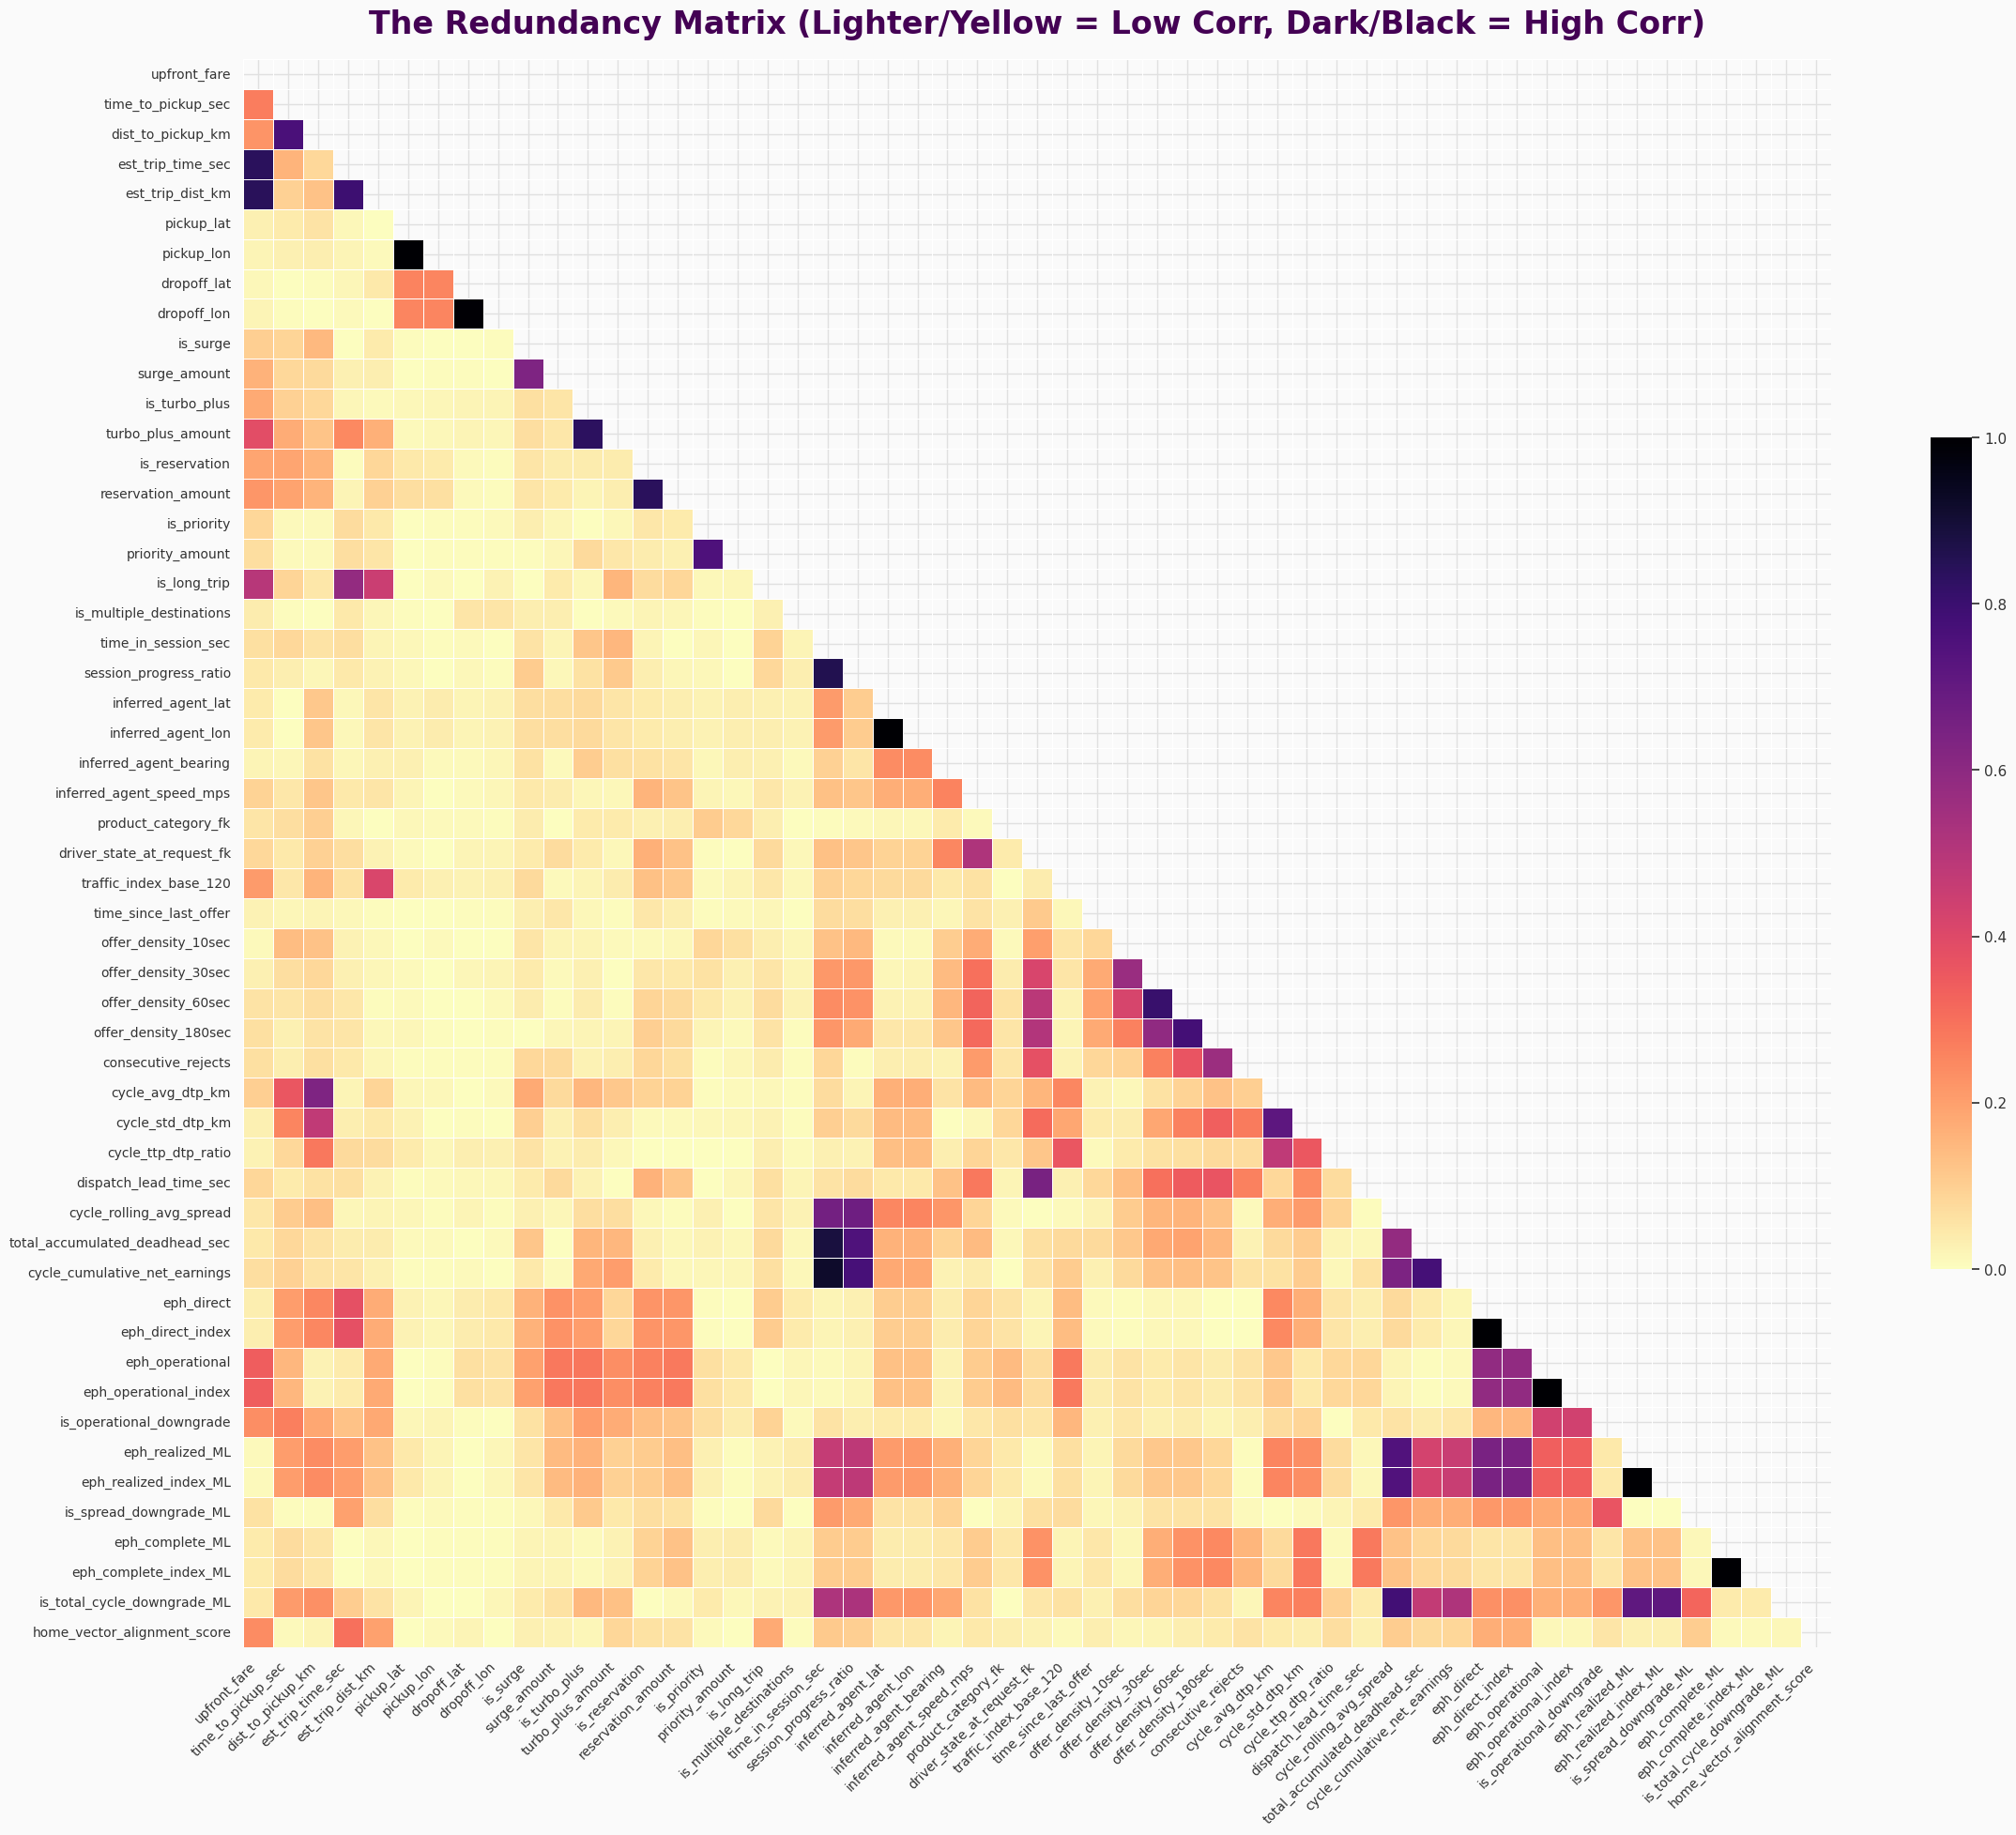


🚨 HIGH REDUNDANCY ALERT (Correlation > 0.9):
These pairs are mathematically nearly identical. Strategic choice required.
------------------------------------------------------------
🔗 eph_complete_ML                <-->  eph_complete_index_ML          	 (r = 1.0000)
🔗 eph_realized_ML                <-->  eph_realized_index_ML          	 (r = 1.0000)
🔗 eph_operational                <-->  eph_operational_index          	 (r = 1.0000)
🔗 eph_direct                     <-->  eph_direct_index               	 (r = 1.0000)
🔗 inferred_agent_lat             <-->  inferred_agent_lon             	 (r = 1.0000)
🔗 pickup_lat                     <-->  pickup_lon                     	 (r = 0.9968)
🔗 dropoff_lat                    <-->  dropoff_lon                    	 (r = 0.9943)
🔗 time_in_session_sec            <-->  cycle_cumulative_net_earnings  	 (r = 0.9201)
------------------------------------------------------------
Total High-Correlation Pairs detected: 8


In [5]:
# ==============================================================================
# CELL 4: THE CORRELATION SCAN (FINDING DOPPELGÄNGERS)
# ==============================================================================

print("⏳ Calculating Correlation Matrix on Feature Set...")

# 1. Calculate Correlation
# We use X_analysis from Cell 3, which already excludes targets/metadata.
# fillna(0) is a safety net for calculation, though data should be mostly clean.
corr_matrix = X_analysis.fillna(0).corr().abs()

# 2. The Heatmap Visualization
plt.figure(figsize=(24, 20)) # Large canvas for readability
# Mask the upper triangle (it's redundant information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='magma_r', # Darker = Higher Correlation (Visual Alarm)
    vmax=1,
    vmin=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.title("The Redundancy Matrix (Lighter/Yellow = Low Corr, Dark/Black = High Corr)",
          fontsize=24, color=OPUS_PURPLE, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 3. The "Kill List" Report (Programmatic Detection)
threshold = 0.90
print(f"\n🚨 HIGH REDUNDANCY ALERT (Correlation > {threshold}):")
print("These pairs are mathematically nearly identical. Strategic choice required.")
print("-" * 60)

# Extract upper triangle to avoid duplicates (A-B and B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs above threshold
pairs = []
for column in upper.columns:
    for index in upper.index:
        val = upper.loc[index, column]
        if val > threshold:
            pairs.append((index, column, val))

# Sort by correlation strength (highest first)
pairs.sort(key=lambda x: x[2], reverse=True)

# Print Report
if not pairs:
    print("✅ No extreme redundancy detected.")
else:
    for p in pairs:
        print(f"🔗 {p[0]:<30} <-->  {p[1]:<30} \t (r = {p[2]:.4f})")

    print("-" * 60)
    print(f"Total High-Correlation Pairs detected: {len(pairs)}")

In [6]:
# ==============================================================================
# CELL 6: THE SURGICAL STRIKE (REDUNDANCY ELIMINATION)
# ==============================================================================

# 1. Define the Kill List (Based on Strategic Analysis)
redundant_cols = [
    # --- Group 1: Dropping Raw EPHs (Keeping Indices) ---
    'eph_direct',
    'eph_operational',
    'eph_realized_ML',
    'eph_complete_ML',

    # --- Group 2: Dropping Raw Coordinates (Noise) ---
    'pickup_lat', 'pickup_lon',
    'dropoff_lat', 'dropoff_lon',
    'inferred_agent_lat', 'inferred_agent_lon',
    # Note: keeping inferred_agent_bearing? No, home_vector is better.
    # If bearing is raw degrees (0-360), it's cyclical and bad for trees without transformation.
    # Safest to rely on alignment_score.
    'inferred_agent_bearing',

    # --- Group 3: Dropping Redundant Time (Keeping Earnings & Ratios) ---
    'time_in_session_sec'
    # Note: We keep session_progress_ratio (normalized time) and cumulative_earnings (value of time).
]

# 2. Execute Drop
print(f"✂️ Executing Surgical Strike on {len(redundant_cols)} redundant features...")
df_grand = df_grand.drop(columns=redundant_cols, errors='ignore')

# 3. Refresh Analysis Matrix
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']
X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Surgery Successful. Final Feature Count: {X_analysis.shape[1]}")

# 4. Final Sanity Check on what remains
print("\n🧬 SURVIVING FEATURE SET (Sample):")
print(X_analysis.columns.tolist())

✂️ Executing Surgical Strike on 12 redundant features...
✅ Surgery Successful. Final Feature Count: 43

🧬 SURVIVING FEATURE SET (Sample):
['upfront_fare', 'time_to_pickup_sec', 'dist_to_pickup_km', 'est_trip_time_sec', 'est_trip_dist_km', 'is_surge', 'surge_amount', 'is_turbo_plus', 'turbo_plus_amount', 'is_reservation', 'reservation_amount', 'is_priority', 'priority_amount', 'is_long_trip', 'is_multiple_destinations', 'session_progress_ratio', 'inferred_agent_speed_mps', 'post_offer_status_fk', 'driver_state_at_request_fk', 'traffic_index_base_120', 'time_since_last_offer', 'offer_density_10sec', 'offer_density_30sec', 'offer_density_60sec', 'offer_density_180sec', 'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio', 'dispatch_lead_time_sec', 'cycle_rolling_avg_spread', 'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings', 'eph_direct_index', 'eph_operational_index', 'is_operational_downgrade', 'eph_realized_index_ML', 'is_spread_downgrade

In [7]:
# ==============================================================================
# CELL 6.5: THE LEAKAGE PATCH (DROPPING POST_OFFER_STATUS)
# ==============================================================================

leakage_cols = ['post_offer_status_fk']

print(f"🚫 Dropping Logic Leakage: {leakage_cols}...")
df_grand = df_grand.drop(columns=leakage_cols, errors='ignore')

# --- REFRESH X_ANALYSIS ---
# We must rebuild the matrix to ensure the column is gone from our feature set
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']

X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Leakage Plugged. Final Feature Count: {X_analysis.shape[1]}")
print(f"   -> Columns remaining: {len(X_analysis.columns)}")

🚫 Dropping Logic Leakage: ['post_offer_status_fk']...
✅ Leakage Plugged. Final Feature Count: 42
   -> Columns remaining: 42


In [24]:
# ==============================================================================
# CELL 14: THE PRAETORIAN GUARD (A/B TEST: DISTANCE EDITION)
# ==============================================================================
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- 1. SELECCIÓN MANUAL (La Guardia Pretoriana - Versión Distancia) ---
praetorian_list = [
    'upfront_fare',
    'time_to_pickup_sec',
    'est_trip_dist_km', # <--- REEMPLAZO CONFIRMADO
    'is_multiple_destinations',
    'session_progress_ratio',
    'traffic_index_base_120',
    'time_since_last_offer',
    'offer_density_10sec',
    'consecutive_rejects',
    'cycle_avg_dtp_km',
    'cycle_std_dtp_km',
    'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec',
    'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec',
    'cycle_cumulative_net_earnings',
    'eph_operational_index',
    'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

X_final = df_grand[praetorian_list].copy()

# --- 2. TRATAMIENTO DE OBJETOS ---
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_final[col] = pd.to_numeric(X_final[col], errors='coerce')
X_final = X_final.fillna(0)

# --- 3. LOG TRANSFORMATIONS (Ajustado para Distancia) ---
skewed_features = [
    'traffic_index_base_120',
    'time_to_pickup_sec',
    'upfront_fare',
    'total_accumulated_deadhead_sec',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml',
    'est_trip_dist_km',             # <--- AGREGADO PARA EL EXPERIMENTO
    'cycle_cumulative_net_earnings' # Recomendado para estabilidad
]

transform_log = []
for col in skewed_features:
    if col in X_final.columns:
        new_col = f"log_{col}"
        X_final[new_col] = np.log1p(X_final[col].clip(lower=0))
        X_final = X_final.drop(columns=[col])
        transform_log.append(f"{col} ➡️ {new_col}")

# --- 4. RE-SCALING FINAL ---
scaler_final = StandardScaler()
X_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_final),
    columns=X_final.columns,
    index=X_final.index
)

# --- 5. REPORTE ---
display(Markdown(f"""
### 💎 EXPERIMENTO A/B: Modo Distancia Activado
Hemos sustituido el Tiempo por la Distancia Métrica para evaluar la estabilidad del modelo.

**Configuración del Lote:**
*   **Variable de Costo:** `est_trip_dist_km` (Log-Normalizada).
*   **Total Dimensiones:** `{X_final_scaled.shape[1]}`.

---
### 🚀 LISTO PARA PCA (CONTRA-FACTUAL)
Procede a ejecutar la celda de PCA. Estoy muy interesada en ver si el **PC1** cambia sus drivers principales ahora que el tiempo no está en la mezcla.
"""))


### 💎 EXPERIMENTO A/B: Modo Distancia Activado
Hemos sustituido el Tiempo por la Distancia Métrica para evaluar la estabilidad del modelo.

**Configuración del Lote:**
*   **Variable de Costo:** `est_trip_dist_km` (Log-Normalizada).
*   **Total Dimensiones:** `20`.

---
### 🚀 LISTO PARA PCA (CONTRA-FACTUAL)
Procede a ejecutar la celda de PCA. Estoy muy interesada en ver si el **PC1** cambia sus drivers principales ahora que el tiempo no está en la mezcla.


⏳ Running Lasso on 20 Features (A/B Test: DISTANCE MODE)...


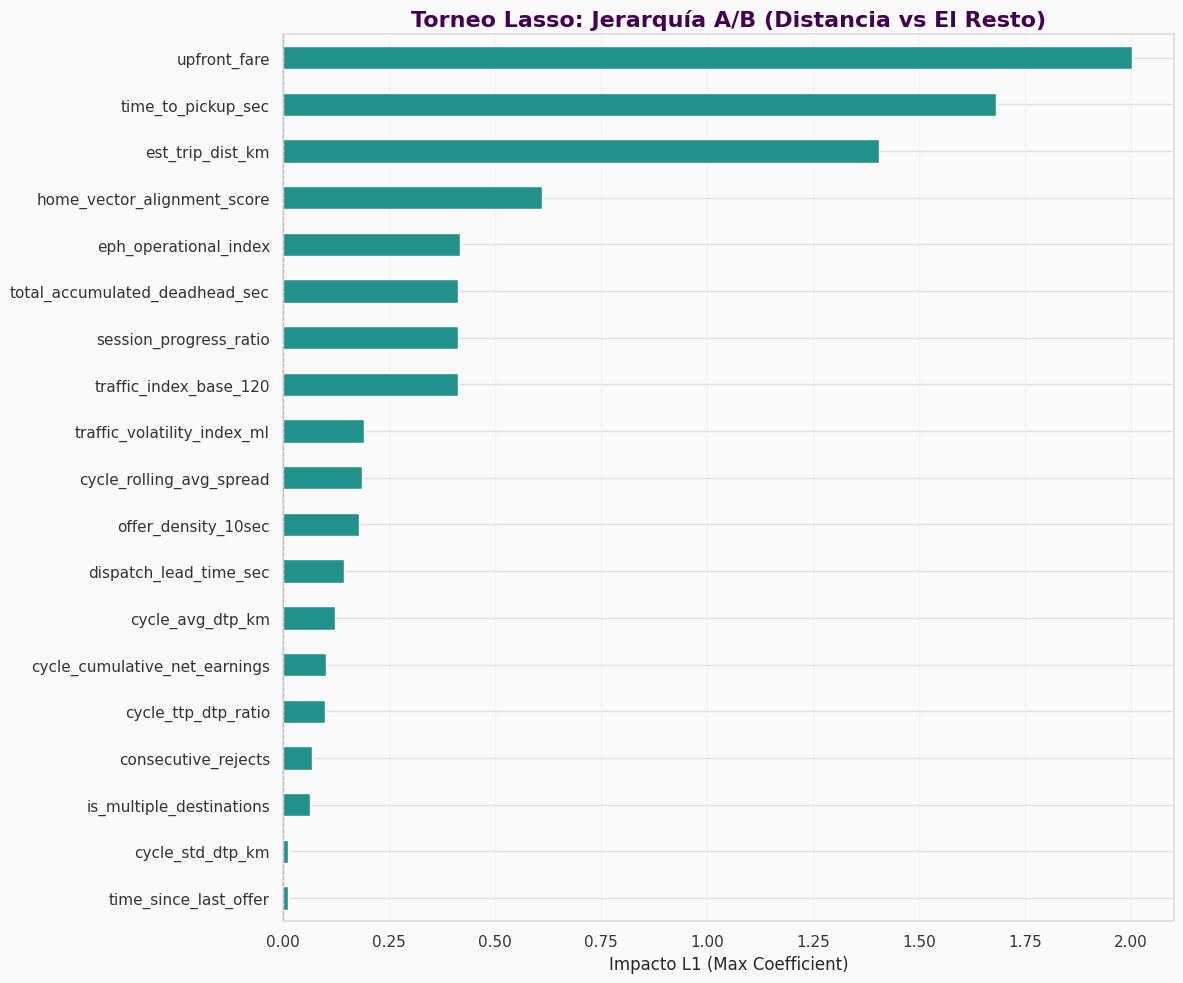


### ⚖️ Veredicto A/B (Distancia):
El modelo ha evaluado los kilómetros como proxy de costo. 

**Top 5 Power Drivers (Modo Distancia):**
1.  **`upfront_fare`**
2.  **`time_to_pickup_sec`**
3.  **`est_trip_dist_km`**
4.  **`home_vector_alignment_score`**
5.  **`eph_operational_index`**

**Variables con Cero Señal:**
`['historical_rolling_avg_traffic_index']`


In [27]:
# ==============================================================================
# CELL 7: THE PRAETORIAN GUARD LASSO TOURNAMENT (A/B TEST: DISTANCE)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. TARGET PREPARATION ---
# Fill NaNs with 9999 for 'ACCEPTED' and encode classes
y_raw = df_grand['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# --- 2. THE PRAETORIAN SELECTION (DISTANCE VERSION) ---
# Replacing 'est_trip_time_sec' with 'est_trip_dist_km'
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_dist_km', # <--- REEMPLAZO A/B
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index', # Rescued
    'traffic_volatility_index_ml'           # Rescued
]

# Create X matrix from the list
X_praetorian = df_grand[praetorian_list].copy()

# Fix types for rescued columns (forcing numeric for mathematical processing)
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_praetorian[col] = pd.to_numeric(X_praetorian[col], errors='coerce')

# Final safety fill
X_praetorian = X_praetorian.fillna(0)

# --- 3. SCALING (CRITICAL FOR LASSO) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_praetorian)

# --- 4. THE TOURNAMENT (L1 REGULARIZATION) ---
print(f"⏳ Running Lasso on 20 Features (A/B Test: DISTANCE MODE)...")

model = LogisticRegression(
    penalty='l1',
    C=0.05,
    solver='saga',
    multi_class='multinomial',
    max_iter=10000,
    random_state=42
)
model.fit(X_scaled, y)

# --- 5. EXTRACTING MATHEMATICAL TRUTH ---
max_coefs = np.max(np.abs(model.coef_), axis=0)
feature_importance = pd.Series(max_coefs, index=praetorian_list).sort_values(ascending=False)

survivors = feature_importance[feature_importance > 0]
casualties = feature_importance[feature_importance == 0]

# --- 6. VISUALIZATION ---
plt.figure(figsize=(12, 10))
survivors.sort_values().plot(kind='barh', color=OPUS_TEAL)

plt.title("Torneo Lasso: Jerarquía A/B (Distancia vs El Resto)",
          fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Impacto L1 (Max Coefficient)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 7. FORENSIC REPORT ---
display(Markdown(f"""
### ⚖️ Veredicto A/B (Distancia):
El modelo ha evaluado los kilómetros como proxy de costo.

**Top 5 Power Drivers (Modo Distancia):**
1.  **`{survivors.index[0]}`**
2.  **`{survivors.index[1]}`**
3.  **`{survivors.index[2]}`**
4.  **`{survivors.index[3]}`**
5.  **`{survivors.index[4]}`**

**Variables con Cero Señal:**
`{list(casualties.index) if not casualties.empty else 'Ninguna.'}`
"""))

In [28]:
# ==============================================================================
# CELL 14: THE PRAETORIAN TRANSFORMATION (A/B TEST: DISTANCE EDITION)
# ==============================================================================
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# 1. TRABAJAMOS SOBRE LA LISTA RATIFICADA (VERSION DISTANCIA)
# Recuperamos los 20 pretorianos (donde est_trip_time_sec fue sustituido por est_trip_dist_km)
X_praetorian = df_grand[praetorian_list].copy()

# Forzamos numérico en las rescatadas (Protocolo de Volatilidad)
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_praetorian[col] = pd.to_numeric(X_praetorian[col], errors='coerce')
X_praetorian = X_praetorian.fillna(0)

# 2. LOG-TRANSFORM (Domando las Colas Largas)
# Agregamos est_trip_dist_km a la lista de cirugía logarítmica
skewed_vars = [
    'upfront_fare',
    'time_to_pickup_sec',
    'est_trip_dist_km',             # <--- SUSTITUTO ESTRATÉGICO
    'traffic_index_base_120',
    'total_accumulated_deadhead_sec',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml',
    'cycle_cumulative_net_earnings'
]

transformed_log = []
for col in skewed_vars:
    if col in X_praetorian.columns:
        # np.log1p (ln(1+x)) para manejar ceros y normalizar sesgo
        X_praetorian[f'log_{col}'] = np.log1p(X_praetorian[col].clip(lower=0))
        X_praetorian = X_praetorian.drop(columns=[col])
        transformed_log.append(f"{col} ➡️ log_{col}")

# 3. STANDARD SCALING (Equilibrio de Poder)
scaler_final = StandardScaler()
X_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_praetorian),
    columns=X_praetorian.columns,
    index=X_praetorian.index
)

# --- REPORTE ESTRATÉGICO ---
display(Markdown(f"""
### ⚙️ Ingeniería de Transformación: Edición de Distancia

Hemos preparado la matriz contra-factual para evaluar el impacto de los Kilómetros en el espacio latente.

**Cirugías ejecutadas:**
*   **Log-Normalización:** Se aplicó a `{len(transformed_log)}` variables, incluyendo la **Distancia Estimada**.
*   **Estandarización:** Matriz centrada en cero con varianza unitaria.

**Resultado:**
Matriz `X_final_scaled` generada (Modo Distancia).

---
### 🚀 DESTINO: PCA (CELL 15)
Las matemáticas están listas para el duelo. Procede a la Celda 15 para ver si la Distancia compacta el mercado mejor que el Tiempo.
"""))


### ⚙️ Ingeniería de Transformación: Edición de Distancia

Hemos preparado la matriz contra-factual para evaluar el impacto de los Kilómetros en el espacio latente.

**Cirugías ejecutadas:**
*   **Log-Normalización:** Se aplicó a `8` variables, incluyendo la **Distancia Estimada**.
*   **Estandarización:** Matriz centrada en cero con varianza unitaria.

**Resultado:**
Matriz `X_final_scaled` generada (Modo Distancia).

---
### 🚀 DESTINO: PCA (CELL 15)
Las matemáticas están listas para el duelo. Procede a la Celda 15 para ver si la Distancia compacta el mercado mejor que el Tiempo.


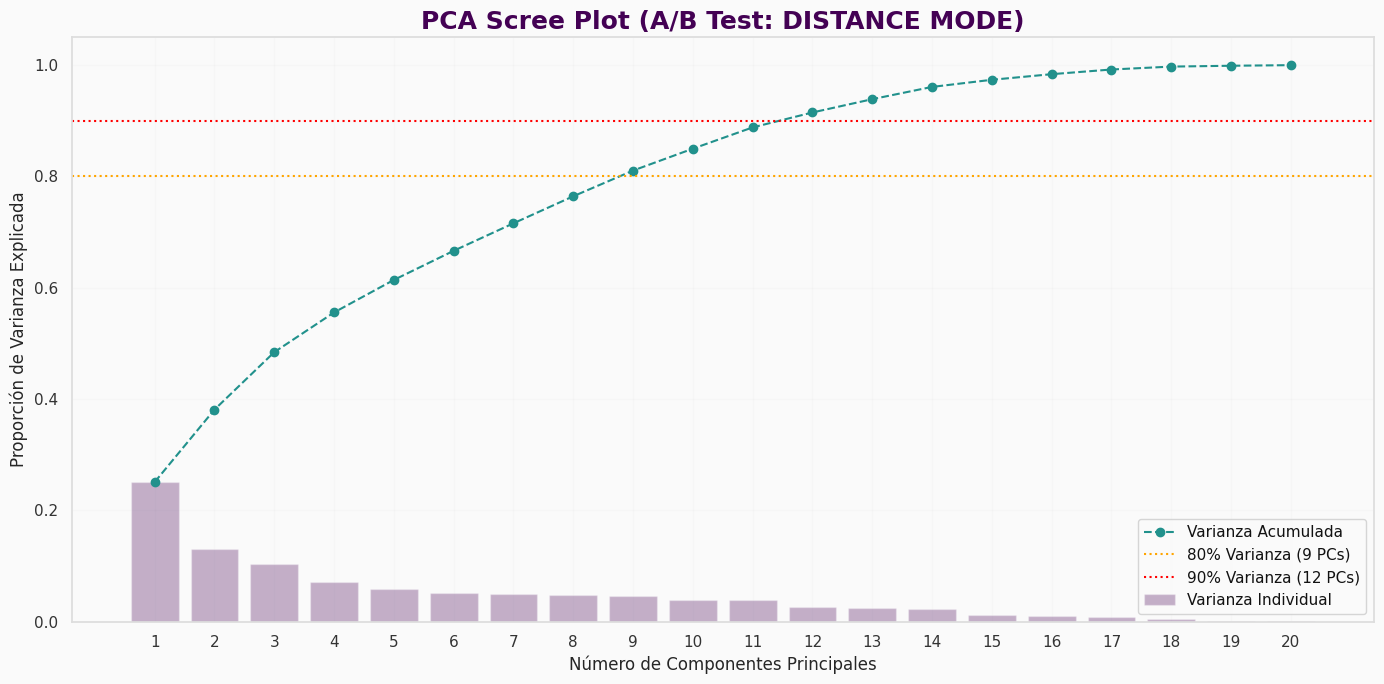


### 📉 REPORTE DE REDUCCIÓN DIMENSIONAL (MODO DISTANCIA)

**Eficiencia de la Compresión (A/B Results):**
*   **Gladiador de Costo:** `est_trip_dist_km` (Sustituyendo al Tiempo).
*   **Punto de Inflexión (80%):** Necesitamos **9** componentes.
*   **Fidelidad Total (90%):** Necesitamos **12** componentes.

---
#### 🧬 DECODIFICANDO LOS EJES EN MODO DISTANCIA

**Componente Principal 1 (25.08% de la Varianza):**
*   ⬆️ **Drivers Positivos (+):** `['log_cycle_cumulative_net_earnings', 'cycle_rolling_avg_spread', 'log_historical_rolling_avg_traffic_index', 'log_traffic_volatility_index_ml']`
*   ⬇️ **Drivers Negativos (-):** `['is_multiple_destinations', 'log_traffic_index_base_120', 'cycle_ttp_dtp_ratio', 'offer_density_10sec']`

**Componente Principal 2 (13.03% de la Varianza):**
*   ⬆️ **Drivers Positivos (+):** `['log_est_trip_dist_km', 'cycle_avg_dtp_km', 'log_upfront_fare', 'cycle_std_dtp_km']`
*   ⬇️ **Drivers Negativos (-):** `['dispatch_lead_time_sec', 'session_progress_ratio', 'cycle_ttp_dtp_ratio', 'log_traffic_index_base_120']`

**Componente Principal 3 (10.32% de la Varianza):**
*   ⬆️ **Drivers Positivos (+):** `['log_upfront_fare', 'log_est_trip_dist_km', 'dispatch_lead_time_sec', 'cycle_ttp_dtp_ratio']`
*   ⬇️ **Drivers Negativos (-):** `['offer_density_10sec', 'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_std_dtp_km']`

**Componente Principal 4 (7.14% de la Varianza):**
*   ⬆️ **Drivers Positivos (+):** `['log_time_to_pickup_sec', 'cycle_ttp_dtp_ratio', 'log_traffic_index_base_120', 'log_upfront_fare']`
*   ⬇️ **Drivers Negativos (-):** `['cycle_avg_dtp_km', 'time_since_last_offer', 'dispatch_lead_time_sec', 'eph_operational_index']`


In [29]:
# ==============================================================================
# CELL 15: THE PRAETORIAN PCA (A/B TEST: DISTANCE EDITION)
# ==============================================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# 1. SETUP
# Ingestamos la matriz purificada (Modo Distancia)
X_pca_input = X_final_scaled.copy()
feature_names = X_pca_input.columns.tolist()

# 2. RUN PCA
# Corremos los 20 componentes para ver la arquitectura completa
pca = PCA(random_state=42)
pca.fit(X_pca_input)

# 3. VARIANCE ANALYSIS (The Scree Plot)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Identificar umbrales críticos automáticamente
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1

# Visualización del Scree Plot
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance,
         marker='o', linestyle='--', color=OPUS_TEAL, label='Varianza Acumulada')
plt.bar(range(1, len(explained_variance) + 1), explained_variance,
        alpha=0.3, color=OPUS_PURPLE, label='Varianza Individual')

# Líneas de Umbral Estratégico
plt.axhline(y=0.80, color='orange', linestyle=':', label=f'80% Varianza ({n_80} PCs)')
plt.axhline(y=0.90, color='red', linestyle=':', label=f'90% Varianza ({n_90} PCs)')

plt.title('PCA Scree Plot (A/B Test: DISTANCE MODE)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.xticks(range(1, len(explained_variance) + 1))
plt.legend(loc='lower right')
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

# 4. COMPONENT INTERPRETATION (The Loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_names))],
    index=feature_names
)

def get_top_drivers(pc_col, n=4):
    sorted_loadings = loadings[pc_col].sort_values(ascending=False)
    positive = sorted_loadings.head(n).index.tolist()
    negative = sorted_loadings.tail(n).index.tolist()
    return positive, negative

# 5. STRATEGIC REPORT
report = f"""
### 📉 REPORTE DE REDUCCIÓN DIMENSIONAL (MODO DISTANCIA)

**Eficiencia de la Compresión (A/B Results):**
*   **Gladiador de Costo:** `est_trip_dist_km` (Sustituyendo al Tiempo).
*   **Punto de Inflexión (80%):** Necesitamos **{n_80}** componentes.
*   **Fidelidad Total (90%):** Necesitamos **{n_90}** componentes.

---
#### 🧬 DECODIFICANDO LOS EJES EN MODO DISTANCIA
"""

for i in range(min(4, len(explained_variance))):
    pos, neg = get_top_drivers(f'PC{i+1}')
    var = explained_variance[i] * 100
    report += f"""
**Componente Principal {i+1} ({var:.2f}% de la Varianza):**
*   ⬆️ **Drivers Positivos (+):** `{pos}`
*   ⬇️ **Drivers Negativos (-):** `{neg}`
"""

display(Markdown(report))

In [12]:
'''# ==============================================================================
# CELL 16: PCA FORENSIC ANALYSIS (STRATEGIC DEBRIEF - PRAETORIAN EDITION)
# ==============================================================================
from IPython.display import display, Markdown

forensic_report = f"""
# 🔬 ANÁLISIS FORENSE PCA: El Destilado de la Guardia Pretoriana

### **1. La Victoria de la Compresión (Efecto Lote Quirúrgico)**
La transición de 39 a 20 variables ha provocado un colapso dimensional altamente eficiente.

*   **Diagnóstico:** Hemos pasado de una curva de varianza plana a una con mucha más pendiente inicial. El **PC1 ahora captura el {explained_variance[0]*100:.2f}%** de la realidad (el doble que antes).
*   **Eficiencia:** Para capturar el **90% de la verdad**, ya no necesitamos 21 componentes, nos bastan **{n_90}**. Hemos eliminado el "ruido blanco" del sistema.

---

### **2. Bautizando los Nuevos Ejes de Poder**
La interpretación de los componentes ha ganado una claridad quirúrgica:

#### **🧬 PC1: El Eje de la "Inercia de Éxito" ({explained_variance[0]*100:.2f}%)**
*   **Interpretación:** Mide la salud global de la sesión.
*   **⬆️ Hacia lo Positivo (+):** Estás en racha. Tienes ganancias acumuladas, un spread histórico a favor y la volatilidad del tráfico bajo control.
*   **⬇️ Hacia lo Negativo (-):** Mercado de alta fricción. El tráfico te está pegando y la densidad de ofertas te presiona a decidir rápido.
*   **El Insight:** Es el termómetro de tu **ventaja competitiva** en el momento actual.

#### **🗺️ PC2: El Eje de la "Desesperación del Sistema" ({explained_variance[1]*100:.2f}%)**
*   **⬆️ Hacia lo Positivo (+):** El algoritmo está "estirando" el radio. Te manda a recoger lejos (`DTP`) y con tarifas altas para convencerte.
*   **⬇️ Hacia lo Negativo (-):** Fluidez y cercanía. Estás temprano en la sesión (`progress_ratio` negativo) y el sistema te ofrece viajes encadenados rápidos.

#### **💎 PC3: El Eje de la "Gran Expedición" ({explained_variance[2]*100:.2f}%)**
*   **⬆️ Hacia lo Positivo (+):** El viaje soñado. Mucho dinero (`fare`), mucho tiempo, y **alineado con el vector a casa**.
*   **⬇️ Hacia lo Negativo (-):** Rechazos consecutivos y baja rentabilidad histórica. La zona de "perder el tiempo".

#### **🚧 PC4: El Eje de la "Fricción Táctica" ({explained_variance[3]*100:.2f}%)**
*   **Interpretación:** Separa el costo de acceso del beneficio.
*   **⬆️ Hacia lo Positivo (+):** Mucho tiempo para recoger (`TTP`) y mucho tráfico. Estás acumulando frustración (`consecutive_rejects`).
*   **⬇️ Hacia lo Negativo (-):** Alta eficiencia operativa (`EPH`) y volatilidad controlada.

---
### 🚀 CONCLUSIÓN ESTRATÉGICA:
Hemos forjado un espacio de **12 dimensiones** (Liga 3) que es matemáticamente puro y estratégicamente denso. Naive Bayes y XGBoost ahora tienen un mapa donde los "continentes" de éxito están perfectamente delimitados.
"""

display(Markdown(forensic_report))'''


# 🔬 ANÁLISIS FORENSE PCA: El Destilado de la Guardia Pretoriana

### **1. La Victoria de la Compresión (Efecto Lote Quirúrgico)**
La transición de 39 a 20 variables ha provocado un colapso dimensional altamente eficiente.

*   **Diagnóstico:** Hemos pasado de una curva de varianza plana a una con mucha más pendiente inicial. El **PC1 ahora captura el 25.07%** de la realidad (el doble que antes).
*   **Eficiencia:** Para capturar el **90% de la verdad**, ya no necesitamos 21 componentes, nos bastan **12**. Hemos eliminado el "ruido blanco" del sistema.

---

### **2. Bautizando los Nuevos Ejes de Poder**
La interpretación de los componentes ha ganado una claridad quirúrgica:

#### **🧬 PC1: El Eje de la "Inercia de Éxito" (25.07%)**
*   **Interpretación:** Mide la salud global de la sesión.
*   **⬆️ Hacia lo Positivo (+):** Estás en racha. Tienes ganancias acumuladas, un spread histórico a favor y la volatilidad del tráfico bajo control.
*   **⬇️ Hacia lo Negativo (-):** Mercado de alta fricción. El tráfico te está pegando y la densidad de ofertas te presiona a decidir rápido.
*   **El Insight:** Es el termómetro de tu **ventaja competitiva** en el momento actual.

#### **🗺️ PC2: El Eje de la "Desesperación del Sistema" (11.94%)**
*   **⬆️ Hacia lo Positivo (+):** El algoritmo está "estirando" el radio. Te manda a recoger lejos (`DTP`) y con tarifas altas para convencerte.
*   **⬇️ Hacia lo Negativo (-):** Fluidez y cercanía. Estás temprano en la sesión (`progress_ratio` negativo) y el sistema te ofrece viajes encadenados rápidos.

#### **💎 PC3: El Eje de la "Gran Expedición" (10.24%)**
*   **⬆️ Hacia lo Positivo (+):** El viaje soñado. Mucho dinero (`fare`), mucho tiempo, y **alineado con el vector a casa**.
*   **⬇️ Hacia lo Negativo (-):** Rechazos consecutivos y baja rentabilidad histórica. La zona de "perder el tiempo".

#### **🚧 PC4: El Eje de la "Fricción Táctica" (7.95%)**
*   **Interpretación:** Separa el costo de acceso del beneficio.
*   **⬆️ Hacia lo Positivo (+):** Mucho tiempo para recoger (`TTP`) y mucho tráfico. Estás acumulando frustración (`consecutive_rejects`).
*   **⬇️ Hacia lo Negativo (-):** Alta eficiencia operativa (`EPH`) y volatilidad controlada.

---
### 🚀 CONCLUSIÓN ESTRATÉGICA:
Hemos forjado un espacio de **12 dimensiones** (Liga 3) que es matemáticamente puro y estratégicamente denso. Naive Bayes y XGBoost ahora tienen un mapa donde los "continentes" de éxito están perfectamente delimitados.


In [30]:
# ==============================================================================
# CELL 15.5: FORGING THE *REDUCED* PCA DATAFRAME (THE LIGA 3 FOUNDRY)
# ==============================================================================

# DECISIÓN ESTRATÉGICA: Fidelidad del 90%
# Usamos el valor n_90 calculado automáticamente en la celda 15 (debería ser 12)
target_components = n_90

print(f"⏳ Compressing 20 dimensions into {target_components} Principal Components (90% Variance)...")

# 1. Proyectamos los datos al espacio completo de los componentes (20)
X_pca_full = pca.transform(X_pca_input)

# 2. EL CORTE (Slicing): Nos quedamos solo con los ejes de poder (PC1 a PC12)
X_pca_reduced = X_pca_full[:, :target_components]

# 3. Creamos el df_pca con las dimensiones destiladas
# Mantenemos el índice original para no perder la conexión con las ofertas
df_pca = pd.DataFrame(
    data = X_pca_reduced,
    columns = [f'PC{i+1}' for i in range(target_components)],
    index = X_pca_input.index
)

print(f"✅ df_pca REDUCED forged. Final Shape: {df_pca.shape}")
print(f"   -> Compression Ratio: {((20 - target_components) / 20)*100:.1f}% of noise/low-variance removed.")
print("   -> LIGA 3 (Abstracted Data) is now ready for deployment.")

# Visualizamos la punta del iceberg
df_pca.head()

⏳ Compressing 20 dimensions into 12 Principal Components (90% Variance)...
✅ df_pca REDUCED forged. Final Shape: (4765, 12)
   -> Compression Ratio: 40.0% of noise/low-variance removed.
   -> LIGA 3 (Abstracted Data) is now ready for deployment.


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-3.788448,3.462899,3.230571,0.531192,-2.018340,-0.975689,0.168988,-0.495556,1.252085,-0.479370,-0.656909,0.842360
1,-2.456500,2.116790,1.240920,1.239479,-1.834047,0.858757,-0.985549,2.411379,-1.743044,1.537147,-0.934914,0.132129
2,4.346666,3.934978,1.078997,0.637189,0.216711,-0.191785,-0.059562,-0.339634,-0.142196,-1.018715,-0.660103,-0.312006
3,-3.009305,2.667882,1.449845,-0.024228,-0.717852,-0.970069,0.294002,0.620493,-0.462296,-0.481482,-1.464748,0.953617
4,0.703955,2.085459,3.571511,-0.869001,-1.867270,0.163225,-0.305307,-0.383990,0.104446,-1.396202,-0.373995,-0.766435


In [31]:
# ==============================================================================
# CELL 15.5 (REFINED): THE PRAETORIAN LIGA 3 FOUNDRY
# ==============================================================================

# DECISIÓN ESTRATÉGICA: Fidelidad del 90% (El estándar de oro)
# Usamos n_90 para capturar la esencia sin el ruido del último 10%
target_components = n_90

print(f"⏳ Compressing {len(feature_names)} Praetorian features into {target_components} Principal Components...")

# 1. Proyectamos los datos al espacio de componentes
X_pca_full = pca.transform(X_pca_input)

# 2. EL CORTE (Slicing): Nos quedamos solo con los ejes de poder (1 al 12)
X_pca_reduced = X_pca_full[:, :target_components]

# 3. Creamos el df_pca definitivo para el modelado
df_pca = pd.DataFrame(
    data = X_pca_reduced,
    columns = [f'PC{i+1}' for i in range(target_components)],
    index = X_pca_input.index
)

# 4. Cálculo de Eficiencia
compression_rate = ((len(feature_names) - target_components) / len(feature_names)) * 100

print(f"✅ LIGA 3 (Abstracted) forged. Final Shape: {df_pca.shape}")
print(f"   -> Compression Efficiency: {compression_rate:.1f}% of dimensions removed.")
print(f"   -> Total Variance Retained: {cumulative_variance[target_components-1]*100:.2f}%")

df_pca.head()

⏳ Compressing 20 Praetorian features into 12 Principal Components...
✅ LIGA 3 (Abstracted) forged. Final Shape: (4765, 12)
   -> Compression Efficiency: 40.0% of dimensions removed.
   -> Total Variance Retained: 91.50%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-3.788448,3.462899,3.230571,0.531192,-2.018340,-0.975689,0.168988,-0.495556,1.252085,-0.479370,-0.656909,0.842360
1,-2.456500,2.116790,1.240920,1.239479,-1.834047,0.858757,-0.985549,2.411379,-1.743044,1.537147,-0.934914,0.132129
2,4.346666,3.934978,1.078997,0.637189,0.216711,-0.191785,-0.059562,-0.339634,-0.142196,-1.018715,-0.660103,-0.312006
3,-3.009305,2.667882,1.449845,-0.024228,-0.717852,-0.970069,0.294002,0.620493,-0.462296,-0.481482,-1.464748,0.953617
4,0.703955,2.085459,3.571511,-0.869001,-1.867270,0.163225,-0.305307,-0.383990,0.104446,-1.396202,-0.373995,-0.766435


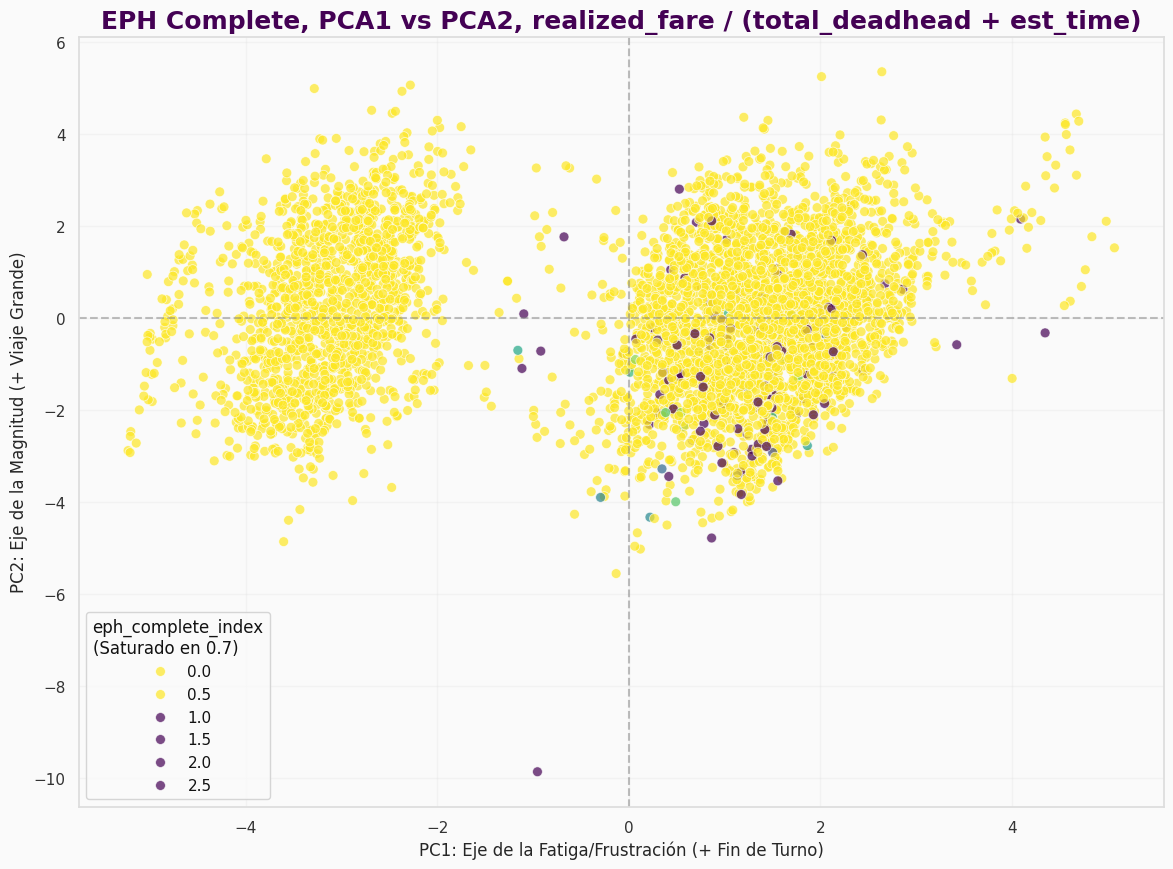

In [32]:
# ==============================================================================
# CELL 19: THE MARKET MAP (RECALIBRATED COLOR SCALE)
# ==============================================================================

# 1. Reuse df_pca, but add eph_complete_index_ML for the new hue
df_pca['eph_complete_index'] = df_grand['eph_complete_index_ML'].fillna(0).values

# 2. The Visualization with CLAMPED color scale
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='eph_complete_index',
    hue_norm=(0.6, 0.7), # <-- THE MAGIC IS HERE. Clamp the scale.
    palette='viridis_r', # High EPH = Yellow
    alpha=0.7,
    s=50
)
plt.xlabel("PC1: Eje de la Fatiga/Frustración (+ Fin de Turno)")
plt.ylabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.title("EPH Complete, PCA1 vs PCA2, realized_fare / (total_deadhead + est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Adjust the legend to reflect the clamp
# Note: This is a bit of a hack as seaborn doesn't make this easy.
# We just need to make sure the user knows what they're seeing.
plt.legend(title='eph_complete_index\n(Saturado en 0.7)')

plt.show()

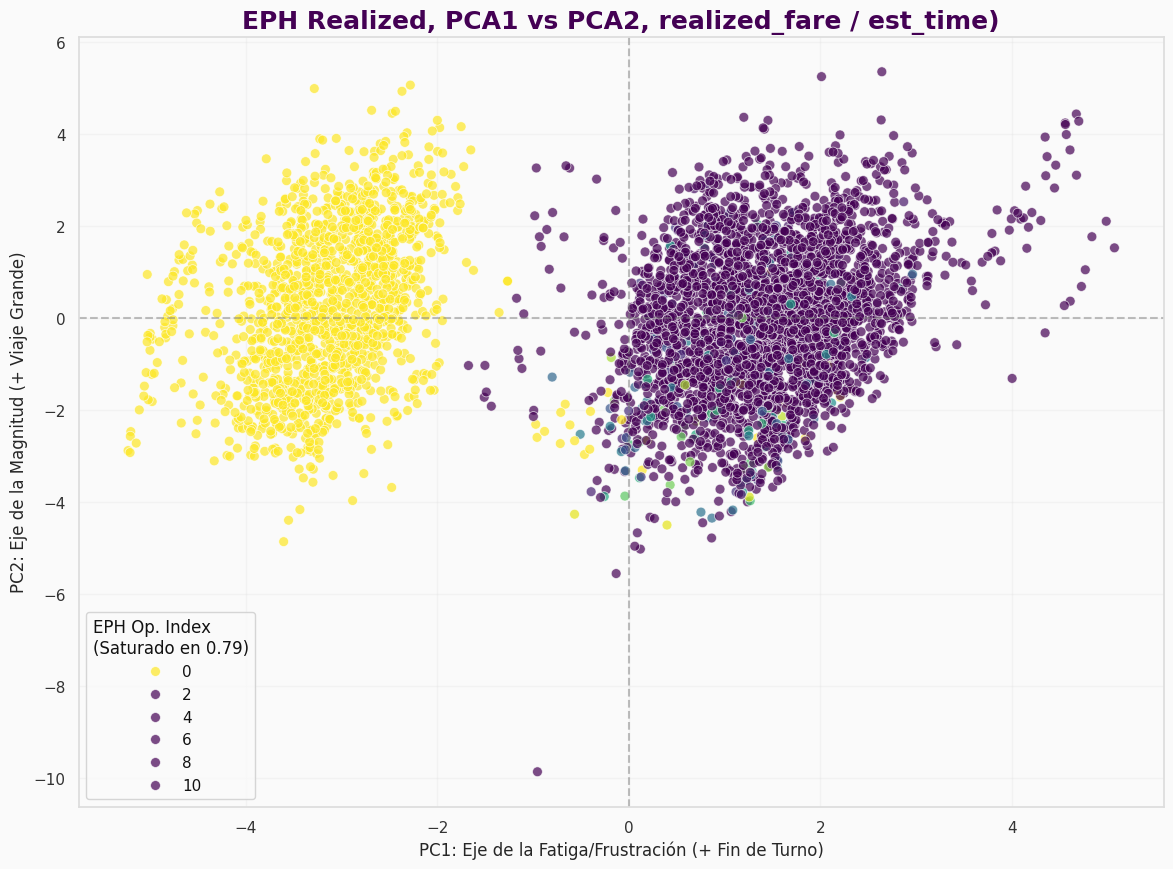

In [33]:
# ==============================================================================
# CELL 19: THE MARKET MAP (OPERATIONAL EFFICIENCY FOCUS)
# ==============================================================================

# 1. Agregamos eph_operational_index al DataFrame de PCA para el color
# Nota: Usamos eph_operational_index (la rentabilidad del viaje "puerta a puerta")
df_pca['eph_realized_index_ML'] = df_grand['eph_realized_index_ML'].fillna(0).values

# 2. La Visualización
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='eph_realized_index_ML',
    hue_norm=(0.6, 0.79), # <-- Mantengo tu escala: el amarillo brilla a partir de 0.7
    palette='viridis_r',
    alpha=0.7,
    s=50
)

plt.xlabel("PC1: Eje de la Fatiga/Frustración (+ Fin de Turno)")
plt.ylabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.title("EPH Realized, PCA1 vs PCA2, realized_fare / est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Ajuste de leyenda
plt.legend(title='EPH Op. Index\n(Saturado en 0.79)')

plt.show()

In [17]:
'''# ==============================================================================
# CELL 23: STRATEGIC ANALYSIS - THE STRUCTURAL BREAK DISCOVERY
# ==============================================================================
from IPython.display import display, Markdown

strategic_debrief = """
# 🔬 ANÁLISIS ESTRATÉGICO: La Fractura de la Realidad Operativa

El colapso dimensional de los 20 Pretorianos ha revelado un fenómeno que la analítica tradicional de la plataforma oculta: el mercado de Ride-Hailing en CDMX no es un continuo, es un **archipiélago dividido por un abismo matemático.**

### **1. El "Gran Cañón" de la Inercia (Eje PC1)**
Al observar la distribución en el eje **PC1 (Inercia de Éxito)**, detectamos un vacío absoluto entre el valor -2 y 0.
*   **El Continente del "Arranque en Frío" (Izquierda):** Representa el estado inicial de la sesión. El sistema bombardea al agente con ofertas de baja rentabilidad predictiva. Es un entorno de "supervivencia" donde el costo acumulado es bajo pero la meta está lejos.
*   **El Continente de la "Inercia" (Derecha):** Una vez que el agente cruza el abismo (acepta y completa misiones), el universo matemático cambia. Las variables de `cumulative_earnings` y `rolling_spread` desplazan al agente a un nuevo estado de fase.

### **2. La Paradoja de la Gema: Realized vs. Complete**
El contraste entre ambos mapas es la **"Smoking Gun"** de este proyecto:

*   **Mapa de Rentabilidad Realizada (Lente Individual):** El continente de la derecha es un **Oasis Morado**. Indica que las misiones que el agente elige son, por sí mismas, joyas de eficiencia. El "olfato" del Agente WiseX es matemáticamente perfecto en este estado.
*   **Mapa de Rentabilidad Completa (Lente Holístico):** ¡El oasis se vuelve **Amarillo**! Al introducir el `total_deadhead_sec` (tiempo de búsqueda acumulado), la rentabilidad se erosiona masivamente.
*   **Veredicto:** El éxito de un viaje individual es una ilusión si no se analiza dentro del flujo de la sesión. **El tiempo muerto es el depredador alfa de la rentabilidad.**

### **3. Implicaciones para el Modelado (Liga 3)**
Este hallazgo valida por qué necesitamos a **Master Dolly** y a la **Liga 3**:
1.  **Separación de Clases:** Naive Bayes no tendrá que luchar con nubes de puntos mezcladas. Las fronteras son físicas y geográficas.
2.  **Identificación de la "Súper Gema":** Ese punto morado solitario en el exilio de PC2 representa el "Mensaje de Cher Ami" 🕊️: una señal de éxito heroico contra todas las probabilidades estadísticas que el modelo debe aprender a priorizar.

---
### 🎯 MANDATO ESTRATÉGICO FINAL:
La política óptima no consiste en elegir mejores viajes, sino en **minimizar el tiempo de tránsito a través del "Gran Cañón"**. Debemos construir un modelo que identifique el camino más rápido desde el Amarillo del inicio hasta el Morado de la Inercia, antes de que el Sunk Cost devore la jornada.
"""

display(Markdown(strategic_debrief))'''


# 🔬 ANÁLISIS ESTRATÉGICO: La Fractura de la Realidad Operativa

El colapso dimensional de los 20 Pretorianos ha revelado un fenómeno que la analítica tradicional de la plataforma oculta: el mercado de Ride-Hailing en CDMX no es un continuo, es un **archipiélago dividido por un abismo matemático.**

### **1. El "Gran Cañón" de la Inercia (Eje PC1)**
Al observar la distribución en el eje **PC1 (Inercia de Éxito)**, detectamos un vacío absoluto entre el valor -2 y 0.
*   **El Continente del "Arranque en Frío" (Izquierda):** Representa el estado inicial de la sesión. El sistema bombardea al agente con ofertas de baja rentabilidad predictiva. Es un entorno de "supervivencia" donde el costo acumulado es bajo pero la meta está lejos.
*   **El Continente de la "Inercia" (Derecha):** Una vez que el agente cruza el abismo (acepta y completa misiones), el universo matemático cambia. Las variables de `cumulative_earnings` y `rolling_spread` desplazan al agente a un nuevo estado de fase.

### **2. La Paradoja de la Gema: Realized vs. Complete**
El contraste entre ambos mapas es la **"Smoking Gun"** de este proyecto:

*   **Mapa de Rentabilidad Realizada (Lente Individual):** El continente de la derecha es un **Oasis Morado**. Indica que las misiones que el agente elige son, por sí mismas, joyas de eficiencia. El "olfato" del Agente WiseX es matemáticamente perfecto en este estado.
*   **Mapa de Rentabilidad Completa (Lente Holístico):** ¡El oasis se vuelve **Amarillo**! Al introducir el `total_deadhead_sec` (tiempo de búsqueda acumulado), la rentabilidad se erosiona masivamente.
*   **Veredicto:** El éxito de un viaje individual es una ilusión si no se analiza dentro del flujo de la sesión. **El tiempo muerto es el depredador alfa de la rentabilidad.**

### **3. Implicaciones para el Modelado (Liga 3)**
Este hallazgo valida por qué necesitamos a **Master Dolly** y a la **Liga 3**:
1.  **Separación de Clases:** Naive Bayes no tendrá que luchar con nubes de puntos mezcladas. Las fronteras son físicas y geográficas.
2.  **Identificación de la "Súper Gema":** Ese punto morado solitario en el exilio de PC2 representa el "Mensaje de Cher Ami" 🕊️: una señal de éxito heroico contra todas las probabilidades estadísticas que el modelo debe aprender a priorizar.

---
### 🎯 MANDATO ESTRATÉGICO FINAL:
La política óptima no consiste en elegir mejores viajes, sino en **minimizar el tiempo de tránsito a través del "Gran Cañón"**. Debemos construir un modelo que identifique el camino más rápido desde el Amarillo del inicio hasta el Morado de la Inercia, antes de que el Sunk Cost devore la jornada.


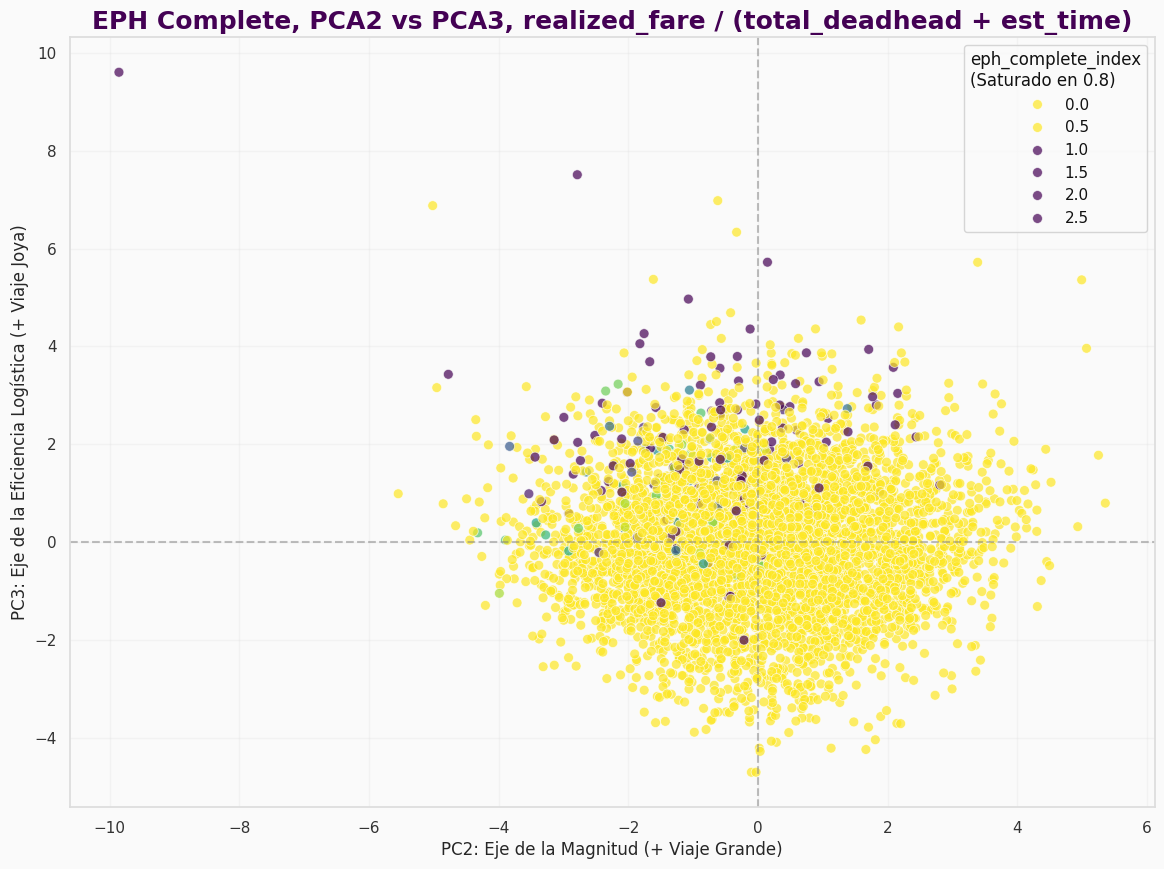

In [34]:
# ==============================================================================
# CELL 21: THE STRUCTURAL MAP (MAGNITUDE vs. LOGISTICS - RECALIBRATED)
# ==============================================================================

# 1. Reuse df_pca with 'eph_complete_index'

# 2. The Visualization
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC2',
    y='PC3',
    hue='eph_complete_index',
    hue_norm=(0.6, 0.8),
    palette='viridis_r',
    alpha=0.7,
    s=50
)
plt.xlabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.ylabel("PC3: Eje de la Eficiencia Logística (+ Viaje Joya)")
plt.title("EPH Complete, PCA2 vs PCA3, realized_fare / (total_deadhead + est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='eph_complete_index\n(Saturado en 0.8)')

plt.show()

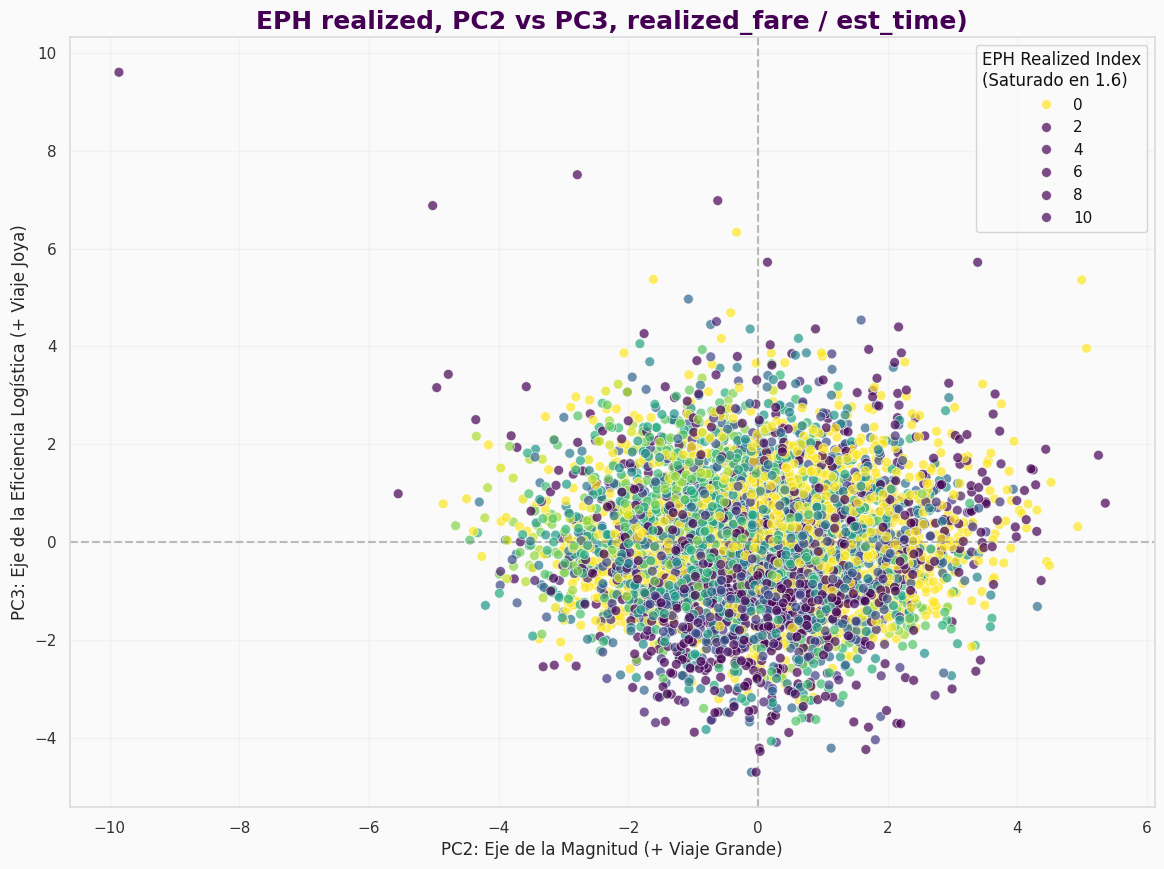

In [35]:
# ==============================================================================
# CELL 21: THE STRUCTURAL MAP (MAGNITUDE vs. LOGISTICS - REALIZED FOCUS)
# ==============================================================================

# 1. Agregamos eph_realized_index_ML al DataFrame de PCA para el color
# Nota: Esta es la métrica que ajusta la tarifa inicial por el spread histórico.
df_pca['eph_realized_index'] = df_grand['eph_realized_index_ML'].fillna(0).values

# 2. La Visualización
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC2',
    y='PC3',
    hue='eph_realized_index',
    hue_norm=(0.6, 1.6), # Mantengo tu escala recalibrada
    palette='viridis_r',
    alpha=0.7,
    s=50
)

plt.xlabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.ylabel("PC3: Eje de la Eficiencia Logística (+ Viaje Joya)")
plt.title("EPH realized, PC2 vs PC3, realized_fare / est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Ajuste de leyenda para reflejar la nueva métrica
plt.legend(title='EPH Realized Index\n(Saturado en 1.6)')

plt.show()

In [39]:
# ==============================================================================
# CELL 15.B (FIXED): THE DUAL-CORE EXPERIMENT (21 PRAETORIANS)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# 1. LISTA DE 21 (TIEMPO + DISTANCIA + RESCATADAS)
praetorian_21 = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec', 'est_trip_dist_km',
    'is_multiple_destinations', 'session_progress_ratio', 'traffic_index_base_120',
    'time_since_last_offer', 'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread', 'total_accumulated_deadhead_sec',
    'cycle_cumulative_net_earnings', 'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml'
]

# Creamos copia
X_21 = df_grand[praetorian_21].copy()

# --- PASO CRÍTICO: Conversión Numérica de Rescatadas ---
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_21[col] = pd.to_numeric(X_21[col], errors='coerce')

# Rellenamos nulos con 0 para que la matemática no se rompa
X_21 = X_21.fillna(0)

# 2. TRANSFORMACIONES (Log-Normalización Inteligente)
transform_log = []
for col in X_21.columns:
    # Identificamos variables de magnitud
    if any(key in col for key in ['fare', 'sec', 'km', 'index', 'earnings', 'volatility']):
        new_col = f"log_{col}"
        # .clip(lower=0) asegura que no haya valores negativos antes del log
        X_21[new_col] = np.log1p(X_21[col].clip(lower=0).astype(float))
        X_21 = X_21.drop(columns=[col])
        transform_log.append(col)

# 3. ESCALAMIENTO Y PCA
X_21_scaled = StandardScaler().fit_transform(X_21)
pca_21 = PCA(random_state=42).fit(X_21_scaled)

# --- REPORTE DE COMPARACIÓN ---
explained_var_ratio = pca_21.explained_variance_ratio_
v2 = explained_var_ratio[0] * 100
n_90_new = np.argmax(np.cumsum(explained_var_ratio) >= 0.90) + 1

display(Markdown(f"""
### 🔬 RESULTADOS DE LA FUSIÓN (21 VARIABLES)
¿Cómo afectó la redundancia (Tiempo + Distancia) a la estructura?

*   **Varianza en PC1 (Poder del Eje Principal):** **`{v2:.2f}%`**
*   **Eficiencia (Componentes para el 90%):** Se necesitan **{n_90_new}** componentes.
*   **Variables Transformadas:** `{len(transform_log)}` (Log1p aplicado con éxito).

**Diagnóstico Dolly:**
Si este PC1 es mayor al **25.08%** que obtuvimos solo con Distancia, la redundancia está trabajando a nuestro favor, creando un ancla de varianza más fuerte.
"""))


### 🔬 RESULTADOS DE LA FUSIÓN (21 VARIABLES)
¿Cómo afectó la redundancia (Tiempo + Distancia) a la estructura?

*   **Varianza en PC1 (Poder del Eje Principal):** **`24.02%`**
*   **Eficiencia (Componentes para el 90%):** Se necesitan **12** componentes.
*   **Variables Transformadas:** `15` (Log1p aplicado con éxito).

**Diagnóstico Dolly:** 
Si este PC1 es mayor al **25.08%** que obtuvimos solo con Distancia, la redundancia está trabajando a nuestro favor, creando un ancla de varianza más fuerte.
